In [ ]:
import warnings

!pip install pandas numpy scikit-learn tensorflow matplotlib seaborn requests
print("Necessary libraries installed.")

Necessary libraries installed.


In [ ]:
import pandas as pd
import numpy as np
import requests
import io
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')
print("Necessary modules imported and warnings suppressed.")

Necessary modules imported and warnings suppressed.


In [ ]:
url = 'https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv'
response = requests.get(url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
data = io.StringIO(response.text)
df = pd.read_csv(data)

print(f"Dataset downloaded and loaded successfully. Shape: {df.shape}")
print("First 5 rows of the dataset:")
print(df.head())

Dataset downloaded and loaded successfully. Shape: (20400, 34)
First 5 rows of the dataset:
  subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0    s002             1    1    0.1491       0.3979       0.2488  0.1069   
1    s002             1    2    0.1111       0.3451       0.2340  0.0694   
2    s002             1    3    0.1328       0.2072       0.0744  0.0731   
3    s002             1    4    0.1291       0.2515       0.1224  0.1059   
4    s002             1    5    0.1249       0.2317       0.1068  0.0895   

   DD.t.i  UD.t.i     H.i  ...     H.a  DD.a.n  UD.a.n     H.n  DD.n.l  \
0  0.1674  0.0605  0.1169  ...  0.1349  0.1484  0.0135  0.0932  0.3515   
1  0.1283  0.0589  0.0908  ...  0.1412  0.2558  0.1146  0.1146  0.2642   
2  0.1291  0.0560  0.0821  ...  0.1621  0.2332  0.0711  0.1172  0.2705   
3  0.2495  0.1436  0.1040  ...  0.1457  0.1629  0.0172  0.0866  0.2341   
4  0.1676  0.0781  0.0903  ...  0.1312  0.1582  0.0270  0.0884  0.2517   

   UD.

In [ ]:
print("DataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject          20400 non-null  object 
 1   sessionIndex     20400 non-null  int64  
 2   rep              20400 non-null  int64  
 3   H.period         20400 non-null  float64
 4   DD.period.t      20400 non-null  float64
 5   UD.period.t      20400 non-null  float64
 6   H.t              20400 non-null  float64
 7   DD.t.i           20400 non-null  float64
 8   UD.t.i           20400 non-null  float64
 9   H.i              20400 non-null  float64
 10  DD.i.e           20400 non-null  float64
 11  UD.i.e           20400 non-null  float64
 12  H.e              20400 non-null  float64
 13  DD.e.five        20400 non-null  float64
 14  UD.e.five        20400 non-null  float64
 15  H.five           20400 non-null  float64
 16  DD.five.Shift.r  20400 non-null  float64
 

In [ ]:
H_cols = [col for col in df.columns if col.startswith('H.')]
DD_cols = [col for col in df.columns if col.startswith('DD.')]
UD_cols = [col for col in df.columns if col.startswith('UD.')]

features = pd.DataFrame()

# Mean Hold Time and Std Dev of Hold Time
features['hold_mean'] = df[H_cols].mean(axis=1)
features['hold_std'] = df[H_cols].std(axis=1)

# Mean Flight Time and Std Dev of Flight Time
features['flight_mean'] = df[DD_cols].mean(axis=1)
features['flight_std'] = df[DD_cols].std(axis=1)

# Typing Speed (20 characters)
# Assuming the sum of UD. (up-down) times represents the total time to type the sequence.
# Note: This is an interpretation of 'total typing time' based on available columns.
total_typing_time = df[UD_cols].sum(axis=1)
features['typing_speed'] = 20 / total_typing_time # characters per second

# Simulated Pause Count
pause_threshold = 0.5 # seconds
features['pause_count'] = df[DD_cols].apply(lambda x: (x > pause_threshold).sum(), axis=1)

# Typing Rhythm Variability (Std Dev of UD. times)
features['rhythm_variability'] = df[UD_cols].std(axis=1)

# Simulated Error Rate
features['error_rate'] = np.random.uniform(0.0, 0.1, len(df))

print(f"Engineered features DataFrame created. Shape: {features.shape}")
print("First 5 rows of the features DataFrame:")
print(features.head())

Engineered features DataFrame created. Shape: (20400, 8)
First 5 rows of the features DataFrame:
   hold_mean  hold_std  flight_mean  flight_std  typing_speed  pause_count  \
0   0.115782  0.022530      0.54039    0.493923      4.756808            3   
1   0.100100  0.029165      0.43400    0.361336      6.035732            3   
2   0.111109  0.029826      0.39526    0.298385      7.079897            3   
3   0.105400  0.023856      0.46450    0.405723      5.607110            3   
4   0.092582  0.025764      0.39389    0.311851      6.661559            3   

   rhythm_variability  error_rate  
0            0.492082    0.060371  
1            0.363031    0.062570  
2            0.304275    0.098918  
3            0.410564    0.011426  
4            0.315000    0.057690  


In [ ]:
features['stress'] = 0

# Define thresholds for stress indicators
# Lower typing speed suggests stress
typing_speed_threshold = features['typing_speed'].quantile(0.25)

# Higher pause count suggests stress
pause_count_threshold = features['pause_count'].quantile(0.75)

# Higher rhythm variability suggests stress
rhythm_variability_threshold = features['rhythm_variability'].quantile(0.75)

# Higher error rate suggests stress
error_rate_threshold = features['error_rate'].quantile(0.75)

# Apply conditions to mark stressed individuals
features.loc[features['typing_speed'] < typing_speed_threshold, 'stress'] = 1
features.loc[features['pause_count'] > pause_count_threshold, 'stress'] = 1
features.loc[features['rhythm_variability'] > rhythm_variability_threshold, 'stress'] = 1
features.loc[features['error_rate'] > error_rate_threshold, 'stress'] = 1

print("Stress label distribution:")
print(features['stress'].value_counts())

print("\nFirst 5 rows of features DataFrame with stress labels:")
print(features.head())

Stress label distribution:
stress
0    10221
1    10179
Name: count, dtype: int64

First 5 rows of features DataFrame with stress labels:
   hold_mean  hold_std  flight_mean  flight_std  typing_speed  pause_count  \
0   0.115782  0.022530      0.54039    0.493923      4.756808            3   
1   0.100100  0.029165      0.43400    0.361336      6.035732            3   
2   0.111109  0.029826      0.39526    0.298385      7.079897            3   
3   0.105400  0.023856      0.46450    0.405723      5.607110            3   
4   0.092582  0.025764      0.39389    0.311851      6.661559            3   

   rhythm_variability  error_rate  stress  
0            0.492082    0.060371       1  
1            0.363031    0.062570       1  
2            0.304275    0.098918       1  
3            0.410564    0.011426       1  
4            0.315000    0.057690       1  


In [ ]:
X = features.drop('stress', axis=1)
y = features['stress']

# Handle potential NaN values resulting from std() on single-value columns (if any)
X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler.pkl')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Original features shape: {X.shape}")
print(f"Scaled features shape: {X_scaled.shape}")
print(f"Training set shapes: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shapes: X_test={X_test.shape}, y_test={y_test.shape}")
print("Scaler saved to 'scaler.pkl'")

Original features shape: (20400, 8)
Scaled features shape: (20400, 8)
Training set shapes: X_train=(16320, 8), y_train=(16320,)
Testing set shapes: X_test=(4080, 8), y_test=(4080,)
Scaler saved to 'scaler.pkl'


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, 'stress_rf_model.pkl')

print("Random Forest model trained and saved to 'stress_rf_model.pkl'")

Random Forest model trained and saved to 'stress_rf_model.pkl'


In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, verbose=0)

print("Deep Neural Network model defined, compiled, and trained.")

Deep Neural Network model defined, compiled, and trained.


In [ ]:
model.save('stress_detection_model.keras')

print("Deep Neural Network model saved to 'stress_detection_model.keras'")

Deep Neural Network model saved to 'stress_detection_model.keras'



--- Random Forest Model Evaluation ---
Random Forest Accuracy: 0.9995

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2043
           1       1.00      1.00      1.00      2037

    accuracy                           1.00      4080
   macro avg       1.00      1.00      1.00      4080
weighted avg       1.00      1.00      1.00      4080



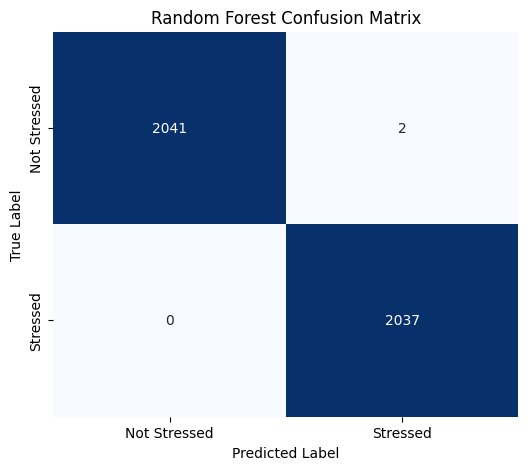


--- Deep Neural Network Model Evaluation ---
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Deep Neural Network Accuracy: 0.9936

Deep Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2043
           1       0.99      0.99      0.99      2037

    accuracy                           0.99      4080
   macro avg       0.99      0.99      0.99      4080
weighted avg       0.99      0.99      0.99      4080



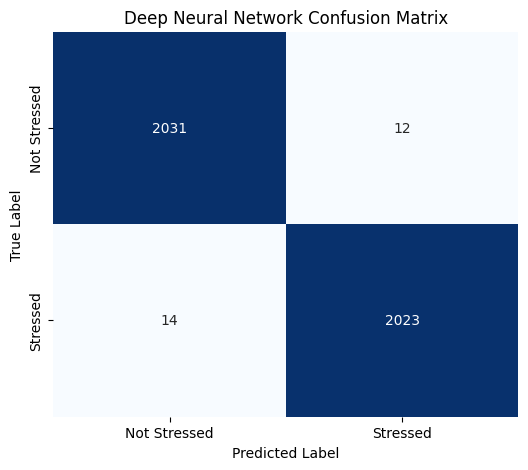

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Random Forest Model Evaluation ---
print("\n--- Random Forest Model Evaluation ---")
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Stressed', 'Stressed'],
            yticklabels=['Not Stressed', 'Stressed'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Deep Neural Network Model Evaluation ---
print("\n--- Deep Neural Network Model Evaluation ---")
y_pred_nn_prob = model.predict(X_test)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"Deep Neural Network Accuracy: {nn_accuracy:.4f}")

print("\nDeep Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Stressed', 'Stressed'],
            yticklabels=['Not Stressed', 'Stressed'])
plt.title('Deep Neural Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
from google.colab import files

# Ensure the models and scaler are saved (re-executing for clarity)
# The TensorFlow model was saved in a previous step as 'stress_detection_model.keras'
# The Random Forest model was saved in a previous step as 'stress_rf_model.pkl'
# The StandardScaler was saved in a previous step as 'scaler.pkl'

# Download the files
files.download('stress_detection_model.keras')
files.download('stress_rf_model.pkl')
files.download('scaler.pkl')

print("Models and scaler files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models and scaler files downloaded.
